Device set to use cpu


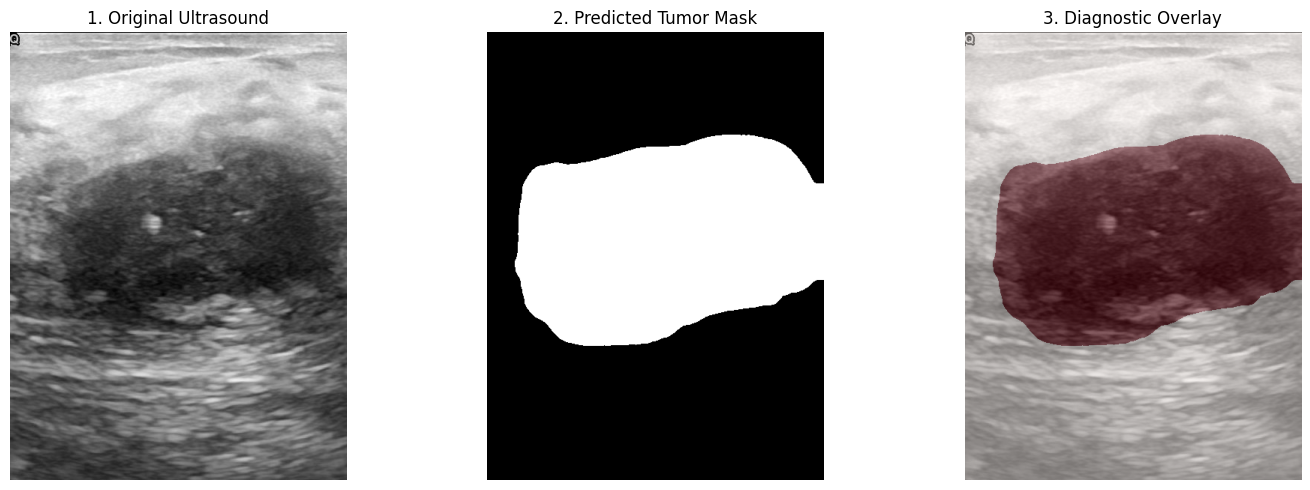

In [2]:
from transformers import pipeline
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import cv2

model_path = 'final_busi_segformer_model'
segmenter = pipeline(task='image-segmentation', model=model_path)

original_image_path = "Dataset_BUSI_with_GT/malignant/malignant (1).png"
original_img = Image.open('data/BUSI/malignant/malignant (1).png')

results = segmenter(original_img)

tumor_mask = None
for entity in results:
    if entity['label'] == 'tumor':
        tumor_mask = entity['mask']
        break

if tumor_mask is None and len(results) > 0:
    tumor_mask = results[0]['mask']

if tumor_mask is None:
    raise ValueError("No segmentation mask was generated by the model.")

mask_array = np.array(tumor_mask)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title("1. Original Ultrasound")
axes[0].axis('off')

axes[1].imshow(mask_array, cmap='gray')
axes[1].set_title("2. Predicted Tumor Mask")
axes[1].axis('off')

axes[2].imshow(original_img, cmap='gray')
axes[2].imshow(mask_array, cmap='Reds', alpha=0.4)
axes[2].set_title("3. Diagnostic Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()

def overlay_mask_transparent_memory(pil_image, pil_mask, alpha=0.4):
    img = cv2.cvtColor(np.array(pil_image.convert("RGB")), cv2.COLOR_RGB2BGR)
    mask = np.array(pil_mask.convert("L"))
    
    if img.shape[:2] != mask.shape:
        mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    color_overlay = np.zeros_like(img)
    color_overlay[:] = [0, 0, 255] 
    
    output = img.copy()
    num_pixels = mask > 0
    output[num_pixels] = cv2.addWeighted(img, 1 - alpha, color_overlay, alpha, 0)[num_pixels]
    
    return Image.fromarray(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))

fused_visualization = overlay_mask_transparent_memory(original_img, tumor_mask, alpha=0.4)
fused_visualization.save("lesion_overlay_transparent.png")
